# Neural Networks for Time Series Classification

In [4]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
#Load tensors
from pathlib import Path

TENSOR_DIR = Path(r"C:\Users\omarl\Downloads\pfizer_tensors")

X_tensor = torch.load(TENSOR_DIR / "X_features.pt")
y_tensor = torch.load(TENSOR_DIR / "y_labels.pt")
fold_tensor = torch.load(TENSOR_DIR / "folds.pt")

print("X:", X_tensor.shape)
print("y:", y_tensor.shape)
print("folds:", fold_tensor.shape)

C:\Users\omarl\AppData\Local\Temp\ipykernel_61216\211932188.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_tensor = torch.load(TENSOR_DIR / "X_features.pt")


X: torch.Size([20931, 86, 65])
y: torch.Size([20931])
folds: torch.Size([20931])


C:\Users\omarl\AppData\Local\Temp\ipykernel_61216\211932188.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  y_tensor = torch.load(TENSOR_DIR / "y_labels.pt")
C:\Users\om

## Import tensors

In [3]:
# Convert to TensorFlow tensors
X_tf = tf.convert_to_tensor(X_tensor.numpy(), dtype=tf.float32)
y_tf = tf.convert_to_tensor(y_tensor.numpy(), dtype=tf.int64)
fold_tf = tf.convert_to_tensor(fold_tensor.cpu().numpy(), dtype=tf.int64)

print(X_tf.shape)
print(y_tf.shape)
print(fold_tf.shape)

(20931, 86, 65)
(20931,)
(20931,)


In [ ]:
# Analyze class distribution
unique_labels, label_counts = np.unique(y_tf.numpy(), return_counts=True)

pd.DataFrame({
    "label": unique_labels,
    "count": label_counts
})

,label,count
0,-1,9032
1,0,6406
2,1,3349
3,2,2144


In [6]:
# Define label names for better visualization
label_names = {
    0: "SEG_A",
    1: "SEG_B",
    2: "SEG_C"
}

target_names = ["SEG_A", "SEG_B", "SEG_C"]

In [7]:
# Filter out unlabeled samples (label = -1)
labeled_mask = y_tf != -1

X_labeled = tf.boolean_mask(X_tf, labeled_mask)
y_labeled = tf.boolean_mask(y_tf, labeled_mask)
fold_labeled = tf.boolean_mask(fold_tf, labeled_mask)

print("Labeled tensors:")
print("X_labeled:", X_labeled.shape)
print("y_labeled:", y_labeled.shape)
print("fold_labeled:", fold_labeled.shape)

Labeled tensors:
X_labeled: (11899, 86, 65)
y_labeled: (11899,)
fold_labeled: (11899,)


In [ ]:
# Analyze class distribution in labeled samples
unique_labeled, counts_labeled = np.unique(y_labeled.numpy(), return_counts=True)

class_dist = pd.DataFrame({
    "class": [label_names[i] for i in unique_labeled],
    "count": counts_labeled,
    "pct": counts_labeled / counts_labeled.sum() * 100
})

class_dist

,class,count,pct
0,SEG_A,6406,53.836457
1,SEG_B,3349,28.145222
2,SEG_C,2144,18.018321


In [ ]:
# Analyze fold distribution in labeled samples
fold_values, fold_counts = np.unique(fold_labeled.numpy(), return_counts=True)

pd.DataFrame({
    "fold": fold_values,
    "count": fold_counts
})

,fold,count
0,0,2380
1,1,2380
2,2,2380
3,3,2380
4,4,2379


## Fold assignment

In [11]:
# Define fold assignments for train/val/test split
test_fold = 0
val_fold = 1

# Create boolean masks for train/val/test splits
train_mask = (fold_labeled != test_fold) & (fold_labeled != val_fold)
val_mask = fold_labeled == val_fold
test_mask = fold_labeled == test_fold

X_train = tf.boolean_mask(X_labeled, train_mask)
y_train = tf.boolean_mask(y_labeled, train_mask)

X_val = tf.boolean_mask(X_labeled, val_mask)
y_val = tf.boolean_mask(y_labeled, val_mask)

X_test = tf.boolean_mask(X_labeled, test_mask)
y_test = tf.boolean_mask(y_labeled, test_mask)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (7139, 86, 65) (7139,)
Val: (2380, 86, 65) (2380,)
Test: (2380, 86, 65) (2380,)


In [12]:
# Function to show class distribution for a given tensor
def show_class_distribution_tf(y_tensor, name):
    y_np = y_tensor.numpy()
    labels, counts = np.unique(y_np, return_counts=True)
    
    df_dist = pd.DataFrame({
        "class": [label_names[i] for i in labels],
        "count": counts,
        "pct": np.round(counts / counts.sum() * 100, 2)
    })
    
    print(name)
    display(df_dist)

show_class_distribution_tf(y_train, "Train distribution")
show_class_distribution_tf(y_val, "Validation distribution")
show_class_distribution_tf(y_test, "Test distribution")

Train distribution


,class,count,pct
0,SEG_A,3843,53.83
1,SEG_B,2010,28.16
2,SEG_C,1286,18.01


Validation distribution


,class,count,pct
0,SEG_A,1281,53.82
1,SEG_B,670,28.15
2,SEG_C,429,18.03


Test distribution


,class,count,pct
0,SEG_A,1282,53.87
1,SEG_B,669,28.11
2,SEG_C,429,18.03


In [13]:
# Compute class weights for imbalanced training data
y_train_np = y_train.numpy()

classes = np.unique(y_train_np)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_np
)

class_weight = dict(zip(classes, weights))

class_weight

{0: 0.6192210946309307, 1: 1.1839137645107793, 2: 1.8504406428201141}

In [14]:
# Print dataset dimensions and number of classes
n_weeks = X_train.shape[1]
n_features = X_train.shape[2]
n_classes = len(target_names)

print("n_weeks:", n_weeks)
print("n_features:", n_features)
print("n_classes:", n_classes)

n_weeks: 86
n_features: 65
n_classes: 3


## Model evaluation and history visualization functions

In [ ]:
# Function to evaluate Keras model performance
def evaluate_keras_model(model, X_test, y_test, target_names):
    proba = model.predict(X_test)
    y_pred = np.argmax(proba, axis=1)
    
    y_true = y_test.numpy()
    
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    
    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)
    print()
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
    display(cm_df)
    
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    
    plt.figure(figsize=(7, 5))
    plt.imshow(cm_norm, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(target_names)), target_names, rotation=45)
    plt.yticks(range(len(target_names)), target_names)
    plt.title("Normalized Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_pred": y_pred,
        "proba": proba
    }

In [20]:
# Function to plot training history
def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    
    plt.figure(figsize=(8, 4))
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(8, 4))
    plt.plot(hist["accuracy"], label="train_accuracy")
    plt.plot(hist["val_accuracy"], label="val_accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

## Dense Neural Network model

In [27]:
# Baseline model
tf.keras.backend.clear_session()

dense_model = models.Sequential([
    layers.Input(shape=(n_weeks, n_features)),
    
    layers.Flatten(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.1),
    
    layers.Dense(n_classes, activation="softmax")
])

dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dense_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 5590)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       715,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 726,083 (2.77 MB)

 Trainable params: 726,083 (2.77 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
#Define callbacks
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

In [29]:
# %%
history_dense = dense_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50


112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4472 - loss: 1.2732 - val_accuracy: 0.5601 - val_loss: 0.9556 - learning_rate: 0.0010
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5347 - loss: 1.0207 - val_accuracy: 0.5950 - val_loss: 0.9200 - learning_rate: 0.0010
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5562 - loss: 0.9816 - val_accuracy: 0.5786 - val_loss: 0.9127 - learning_rate: 0.0010
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5800 - loss: 0.9507 - val_accuracy: 0.6021 - val_loss: 0.8997 - learning_rate: 0.0010
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5974 - loss: 0.9103 - val_accuracy: 0.6109 - val_loss: 0.8919 - learning_rate: 0.0010
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6413 - loss: 0.8738 - val_accuracy: 0.6122 - val_loss: 0.9089 - learning_rate: 0.0010
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6348 - loss: 0.8694 - val_accurac

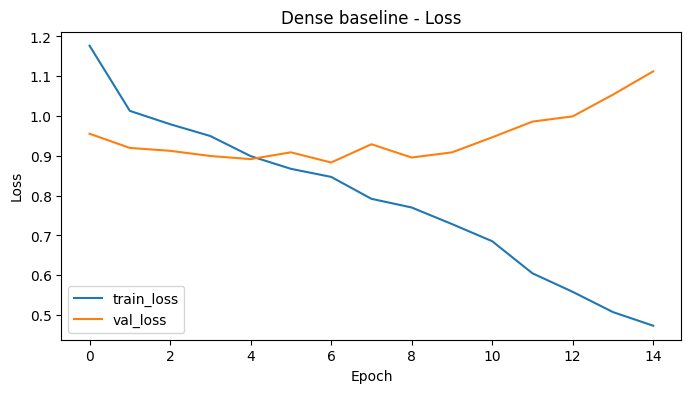

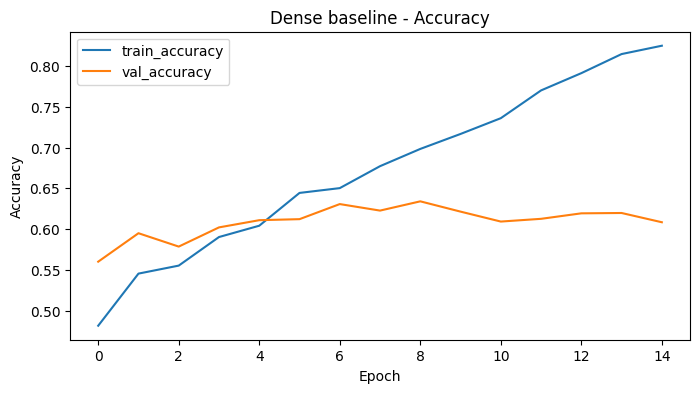

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.6394957983193277
Macro F1: 0.5752399744252773
Weighted F1: 0.6399408578655188

              precision    recall  f1-score   support

       SEG_A       0.77      0.77      0.77      1282
       SEG_B       0.55      0.52      0.53       669
       SEG_C       0.41      0.44      0.43       429

    accuracy                           0.64      2380
   macro avg       0.57      0.58      0.58      2380
weighted avg       0.64      0.64      0.64      2380



,SEG_A,SEG_B,SEG_C
SEG_A,987,166,129
SEG_B,182,345,142
SEG_C,118,121,190


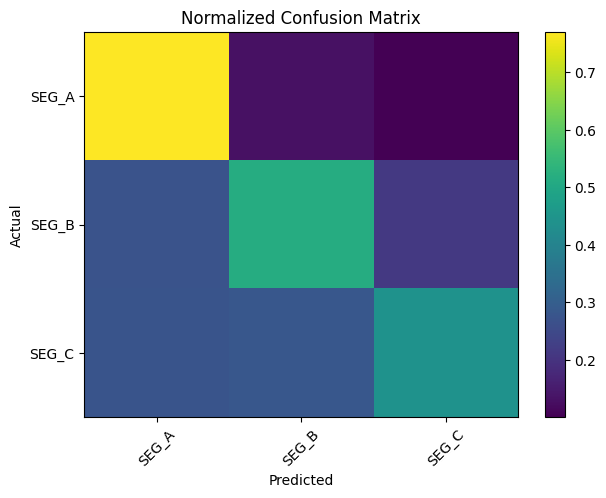

In [30]:
# %%
plot_history(history_dense, "Dense baseline")

dense_results = evaluate_keras_model(
    dense_model,
    X_test,
    y_test,
    target_names
)

## CNN model

In [22]:
# CNN model
tf.keras.backend.clear_session()

cnn_model = models.Sequential([
    layers.Input(shape=(n_weeks, n_features)),
    
    layers.BatchNormalization(),
    
    layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    
    layers.Conv1D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.25),
    
    layers.Conv1D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    
    layers.GlobalAveragePooling1D(),
    
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(n_classes, activation="softmax")
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 86, 65)         │           260 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 86, 64)         │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 86, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 43, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 43, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 21, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 21, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,519 (377.03 KB)

 Trainable params: 95,749 (374.02 KB)

 Non-trainable params: 770 (3.01 KB)

In [24]:
# Define callbacks for CNN model
early_stop_cnn = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr_cnn = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

In [25]:
# %%
history_cnn = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop_cnn, reduce_lr_cnn],
    verbose=1
)

Epoch 1/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5006 - loss: 1.0553 - val_accuracy: 0.4983 - val_loss: 1.0130 - learning_rate: 0.0010
Epoch 2/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5843 - loss: 0.9333 - val_accuracy: 0.6021 - val_loss: 0.8982 - learning_rate: 0.0010
Epoch 3/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6012 - loss: 0.9238 - val_accuracy: 0.6261 - val_loss: 0.8571 - learning_rate: 0.0010
Epoch 4/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6256 - loss: 0.8862 - val_accuracy: 0.6147 - val_loss: 0.8657 - learning_rate: 0.0010
Epoch 5/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6312 - loss: 0.8756 - val_accuracy: 0.6248 - val_loss: 0.8626 - learning_rate: 0.0010
Epoch 6/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6265 - loss: 0.8637 - val_accuracy: 0.6105 - val_loss: 0.8622 - learning_rate: 0.0010
Epoch 7/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6323 - loss: 0.

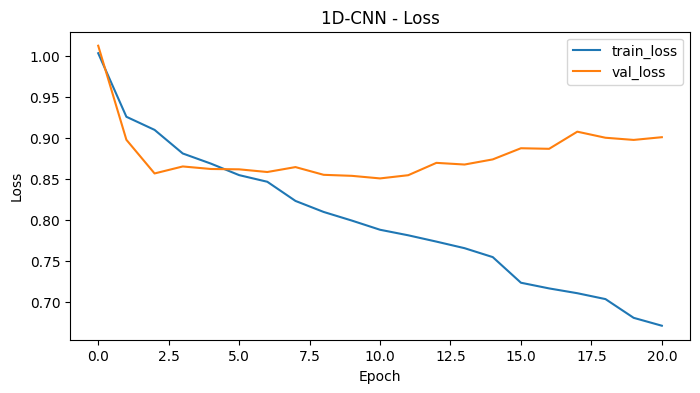

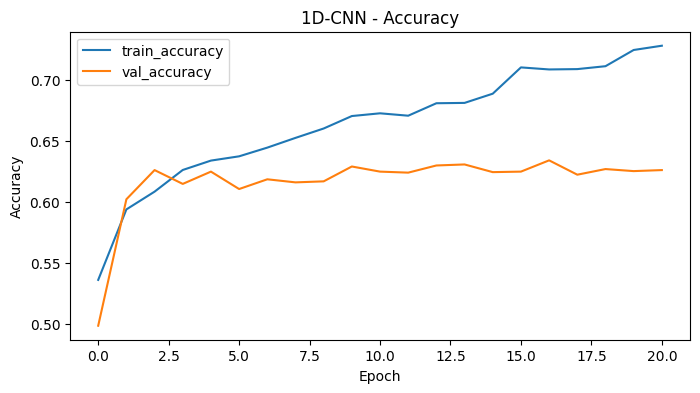

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.6323529411764706
Macro F1: 0.5696807702863391
Weighted F1: 0.6374765625883084

              precision    recall  f1-score   support

       SEG_A       0.78      0.75      0.77      1282
       SEG_B       0.58      0.52      0.55       669
       SEG_C       0.36      0.45      0.40       429

    accuracy                           0.63      2380
   macro avg       0.57      0.57      0.57      2380
weighted avg       0.65      0.63      0.64      2380



,SEG_A,SEG_B,SEG_C
SEG_A,967,130,185
SEG_B,162,346,161
SEG_C,116,121,192


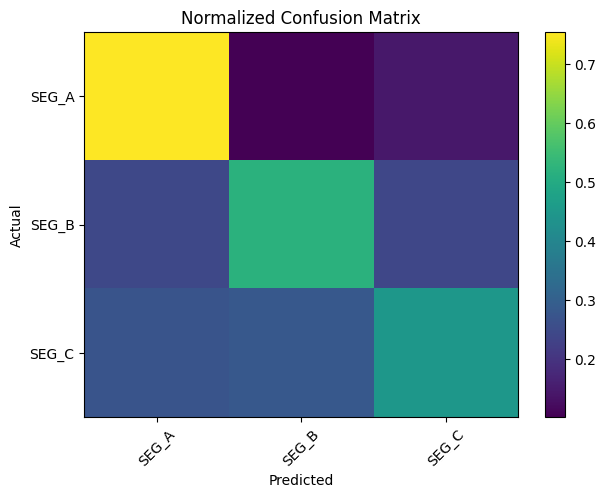

In [26]:
# %%
plot_history(history_cnn, "1D-CNN")

cnn_results = evaluate_keras_model(
    cnn_model,
    X_test,
    y_test,
    target_names
)